# Mapas Auto-Organizáveis (SOM) com Aprendizado Não Supervisionado

**Disciplina:** Inteligência Computacional / Machine Learning — CESUPA

**Professora:** Polyana Santos Fonseca Nascimento

**Integrantes:** Rafael Batista Ferreira e Paulo Ricardo da Rocha Cunha

**Dataset:** Air Quality UCI (o mesmo do trabalho de MLP)

### Declaração de uso de IA Generativa

> **Atenção, equipe:** rascunho a ser revisado e completado por vocês antes da entrega. Ajustem principalmente o que foi feito por vocês e as medidas de validação.

- **Ferramenta utilizada:** Claude Code (Anthropic), modelo Claude Opus, executado na extensão do VS Code.
- **Finalidade do uso:** gerar o código e os textos deste notebook a partir do enunciado do trabalho e do notebook de MLP da equipe: preparação dos dados, configuração e treinamento da SOM, visualizações, segmentação do mapa em regiões, relação com a MLP e redação das interpretações.
- **Extensão aproximada da contribuição:** alta. A estrutura do notebook, o código e a primeira versão de todos os textos interpretativos foram produzidos pela IA. As interpretações foram escritas a partir das saídas reais do notebook executado.
- **Medidas adotadas para validação:**
  - execução completa do notebook e conferência de que todos os números citados nos textos correspondem às saídas;
  - reprodução do modelo final do trabalho de MLP, com o mesmo RMSE de teste de 0,162;
  - verificação das escolhas de hiperparâmetros contra heurísticas da literatura (5·√N neurônios, razão dos autovalores da PCA);
  - revisão dos textos pela equipe _(completar: quem revisou, o que foi alterado, que conceitos foram estudados para a defesa)_.

## 1. Dataset e alterações em relação ao trabalho de MLP

Utilizamos o **mesmo dataset do trabalho de MLP**: o [Air Quality Data Set (UCI)](https://archive.ics.uci.edu/dataset/360/air+quality). Ele traz medições horárias de um equipamento multissensor de baixo custo instalado em uma cidade italiana (março/2004 a abril/2005), junto com as concentrações de referência de um analisador certificado. No trabalho de MLP, a tarefa foi prever a concentração de benzeno `C6H6(GT)` (regressão). A contextualização completa e a análise exploratória estão naquele notebook e não são repetidas aqui.

Neste trabalho, a SOM é usada como ferramenta de **análise exploratória**: descobrir como as observações se organizam no espaço dos sensores, sem usar a variável-alvo no treinamento, e depois relacionar essa organização ao benzeno e aos erros da MLP.

**Pré-processamento reaproveitado do trabalho de MLP** (sem alterações):
- leitura com `;` como separador e `,` como decimal; remoção das colunas e linhas totalmente vazias;
- descarte de `NMHC(GT)` (~90% de valores ausentes);
- remoção das 366 linhas sem a variável-alvo, que são os instantes em que todo o equipamento sensor ficou fora do ar;
- criação de `DateTime`, ordenação cronológica e extração de `hour`, `month` e `dayofweek`.

**Alterações para a SOM** (detalhadas na Seção 2):
1. **Entradas da SOM:** apenas os 5 sensores de baixo custo e as 3 variáveis ambientais (8 atributos), em vez dos 14 atributos usados na MLP.
2. **Gases de referência sem imputação:** `CO(GT)`, `NOx(GT)` e `NO2(GT)` não entram no treinamento e **não são imputados pela mediana**. As falhas do analisador ficam como ausentes, e esses gases são usados apenas na interpretação, com os valores realmente medidos.
3. **Atributos de calendário fora do treinamento:** `hour`, `month` e `dayofweek` também ficam fora do treinamento e são usados só para interpretar o mapa.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, TwoSlopeNorm
from scipy.sparse import lil_matrix

from minisom import MiniSom  # pip install minisom
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# cores categoricas (uma por regiao do mapa), sempre na mesma ordem
CORES_REGIOES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']

In [2]:
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'])
df = df.dropna(how='all', subset=['Date'])
df = df.drop(columns=['NMHC(GT)'])
df = df[df['C6H6(GT)'] != -200].copy()

df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')
df = df.sort_values('DateTime').reset_index(drop=True)
df['hour'] = df['DateTime'].dt.hour
df['month'] = df['DateTime'].dt.month
df['dayofweek'] = df['DateTime'].dt.dayofweek

# Gases do analisador de referencia: falhas (-200) viram NaN e NAO sao imputadas aqui
GASES_REF = ['CO(GT)', 'NOx(GT)', 'NO2(GT)']
df[GASES_REF] = df[GASES_REF].replace(-200, np.nan)

print('Observacoes apos a limpeza:', len(df))
print('Periodo:', df['DateTime'].min(), 'a', df['DateTime'].max())
print('\nPercentual de valores ausentes nos gases de referencia:')
print((df[GASES_REF].isna().mean() * 100).round(1))

Observacoes apos a limpeza: 8991
Periodo: 2004-03-10 18:00:00 a 2005-04-04 14:00:00

Percentual de valores ausentes nos gases de referencia:
CO(GT)     18.3
NOx(GT)    17.7
NO2(GT)    17.8
dtype: float64


## 2. Preparação dos dados

### 2.1. Seleção das entradas

A SOM é treinada com **8 atributos**: as leituras dos 5 sensores de óxido de metal do equipamento de baixo custo (`PT08.S1` a `PT08.S5`) e as 3 variáveis ambientais (`T`, `RH`, `AH`). As escolhas:

- **Variável-alvo `C6H6(GT)` fora do treinamento**, como pede o enunciado. Ela é usada só depois, para colorir o mapa e interpretar as regiões.
- **Gases do analisador de referência (`CO(GT)`, `NOx(GT)`, `NO2(GT)`) fora do treinamento.** Eles vêm do equipamento caro, que é justamente o que se quer substituir, e têm cerca de 18% de falhas. Na MLP essas falhas foram imputadas pela mediana, mas na SOM isso criaria milhares de pontos artificiais com o mesmo valor, que tenderiam a formar um agrupamento falso no mapa. Assim, a SOM organiza os dados exatamente como o equipamento de baixo custo os enxerga, e não há nenhuma imputação nas entradas.
- **Atributos de calendário (`hour`, `month`, `dayofweek`) fora do treinamento.** São variáveis cíclicas: na distância euclidiana, 23h e 0h ficariam distantes, embora sejam vizinhas. Elas são usadas depois, para verificar se as regiões do mapa correspondem a padrões horários ou sazonais.

### 2.2. Normalização

A SOM compara observações e protótipos pela **distância euclidiana**, então atributos com escalas maiores dominariam o treinamento: `PT08.S1(CO)` está na casa dos milhares, enquanto `AH` está na casa de décimos. Por isso aplicamos `StandardScaler` (média 0 e desvio-padrão 1 em cada atributo), a mesma padronização usada na MLP. Como a SOM é usada aqui para análise exploratória, e não para prever dados novos, o padronizador é ajustado sobre todo o conjunto.

In [3]:
ENTRADAS_SOM = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
ALVO = 'C6H6(GT)'

y = df[ALVO].values  # separado: NAO e usado no treinamento da SOM
scaler_som = StandardScaler()
X_som = scaler_som.fit_transform(df[ENTRADAS_SOM].values)

print('Matriz de entrada da SOM:', X_som.shape)
print('Valores ausentes nas entradas:', np.isnan(X_som).sum())
df[ENTRADAS_SOM].describe().T[['mean', 'std', 'min', 'max']].round(2)

Matriz de entrada da SOM: (8991, 8)
Valores ausentes nas entradas: 0


,mean,std,min,max
PT08.S1(CO),1099.83,217.08,647.00,2040.00
PT08.S2(NMHC),939.15,266.83,383.00,2214.00
PT08.S3(NOx),835.49,256.82,322.00,2683.00
PT08.S4(NO2),1456.26,346.21,551.00,2775.00
PT08.S5(O3),1022.91,398.48,221.00,2523.00
T,18.32,8.83,-1.90,44.60
RH,49.23,17.32,9.20,88.70
AH,1.03,0.40,0.18,2.23


## 3. Configuração e treinamento da SOM

| Hiperparâmetro | Valor | Justificativa |
|---|---|---|
| Dimensões da malha | **25 × 19** (475 neurônios) | Heurística de Vesanto: ≈ 5·√N neurônios (≈ 474 para N = 8.991). A razão entre os lados (≈ 1,3) acompanha a razão √(λ₁/λ₂) ≈ 1,5 entre os dois maiores autovalores da PCA, para que a malha siga o formato dos dados. |
| Topologia | retangular | Facilita a visualização e o cálculo das vizinhanças. |
| Inicialização | PCA (`pca_weights_init`) | Os pesos iniciais são distribuídos no plano das duas componentes principais. O treino converge mais rápido e o resultado não depende de uma inicialização aleatória. |
| Número de iterações | **50.000** | Cerca de 5,6 épocas (cada iteração apresenta uma observação sorteada). Mais iterações não reduziram os erros de forma relevante. |
| sigma (raio da vizinhança) | **6,25 → 1** (decaimento linear) | Começa com ¼ do lado maior da malha, para ordenar o mapa globalmente, e termina em 1, para que no final cada neurônio se ajuste quase só aos seus próprios dados. |
| Taxa de aprendizagem | **0,5 → 0** (decaimento linear) | Valor inicial usual; a queda até zero estabiliza os protótipos no fim do treino. |
| Função de vizinhança | gaussiana | Influência suave, que diminui com a distância na malha. |

Não fazemos busca exaustiva de hiperparâmetros. A célula abaixo só calcula os números da heurística, e a seguinte compara três tamanhos de malha para confirmar que a escolha é razoável.

In [4]:
N = len(X_som)
autovalores = np.linalg.eigvalsh(np.cov(X_som.T))[::-1]
print(f'Heuristica 5*sqrt(N): {5 * np.sqrt(N):.0f} neuronios')
print(f'Razao sugerida entre os lados sqrt(l1/l2): {np.sqrt(autovalores[0] / autovalores[1]):.2f}')
print('Variancia explicada pelas componentes principais (%):', (100 * autovalores / autovalores.sum()).round(1))

Heuristica 5*sqrt(N): 474 neuronios
Razao sugerida entre os lados sqrt(l1/l2): 1.48
Variancia explicada pelas componentes principais (%): [53.1 24.3 14.8  4.3  1.3  1.1  0.5  0.4]


In [5]:
SOM_PARAMS = dict(
    learning_rate=0.5,
    neighborhood_function='gaussian',
    topology='rectangular',
    decay_function='linear_decay_to_zero',
    sigma_decay_function='linear_decay_to_one',
    random_seed=RANDOM_STATE,
)
N_ITERACOES = 50_000

def treinar_som(linhas, colunas, sigma, n_iter=N_ITERACOES):
    som = MiniSom(linhas, colunas, X_som.shape[1], sigma=sigma, **SOM_PARAMS)
    som.pca_weights_init(X_som)
    som.train(X_som, n_iter, random_order=True)
    return som

comparacao = []
for linhas, colunas in [(15, 12), (20, 15), (25, 19)]:
    t0 = time.time()
    som_teste = treinar_som(linhas, colunas, sigma=max(linhas, colunas) / 4)
    comparacao.append({
        'malha': f'{linhas} x {colunas}',
        'neuronios': linhas * colunas,
        'erro_quantizacao': som_teste.quantization_error(X_som),
        'erro_topografico': som_teste.topographic_error(X_som),
        'tempo_s': time.time() - t0,
    })
pd.DataFrame(comparacao).round(3)

,malha,neuronios,erro_quantizacao,erro_topografico,tempo_s
0,15 x 12,180,0.908,0.016,1.492
1,20 x 15,300,0.820,0.022,1.925
2,25 x 19,475,0.766,0.019,2.496


In [6]:
LINHAS, COLUNAS = 25, 19
SIGMA = max(LINHAS, COLUNAS) / 4

t0 = time.time()
som = treinar_som(LINHAS, COLUNAS, SIGMA)
print(f'SOM {LINHAS} x {COLUNAS} treinada em {time.time() - t0:.1f}s')

erro_quantizacao = som.quantization_error(X_som)
erro_topografico = som.topographic_error(X_som)
print(f'Erro de quantizacao: {erro_quantizacao:.3f}')
print(f'Erro topografico:    {erro_topografico:.3f} ({100 * erro_topografico:.1f}% das observacoes)')

# BMU (neuronio vencedor) de cada observacao
bmus = np.array([som.winner(x) for x in X_som])
df['bmu_x'], df['bmu_y'] = bmus[:, 0], bmus[:, 1]
pesos = som.get_weights()  # (LINHAS, COLUNAS, n_atributos), na escala padronizada

SOM 25 x 19 treinada em 2.4s
Erro de quantizacao: 0.766
Erro topografico:    0.019 (1.9% das observacoes)


## 4. Avaliação e visualização

### 4.1. Erro de quantização e erro topográfico

- **Erro de quantização:** distância euclidiana média entre cada observação e o protótipo do seu BMU (*Best Matching Unit*, o neurônio mais parecido com ela). Mede a **fidelidade** do mapa, ou seja, o quanto os protótipos representam bem os dados. Como as entradas estão padronizadas, o valor está em "desvios-padrão" no espaço de 8 dimensões.
- **Erro topográfico:** fração das observações cujo primeiro e segundo BMUs **não são vizinhos** na malha. Mede a **preservação da topologia**, ou seja, se observações parecidas caem em neurônios próximos no mapa.

**Resultado:** erro de quantização = **0,766** e erro topográfico = **0,019** (1,9% das observações).

- **Erro de quantização:** para efeito de comparação, a distância típica de uma observação padronizada até a média do dataset é da ordem de √8 ≈ 2,8. Um erro de 0,77 indica que cada protótipo fica bem mais próximo das observações que representa do que a média geral ficaria. A comparação entre malhas mostra o compromisso esperado: mais neurônios dão mais fidelidade (0,908 com 180 neurônios → 0,820 com 300 → 0,766 com 475), mas o ganho vai diminuindo, o que justifica não aumentar mais a malha.
- **Erro topográfico:** 1,9% é baixo; valores abaixo de ~5% costumam indicar boa preservação da topologia. Ou seja, em 98% dos casos os dois neurônios mais parecidos com uma observação são vizinhos na malha, e regiões próximas no mapa representam dados parecidos. Esse erro ficou estável entre os três tamanhos testados (1,6% a 2,2%), então aumentar a malha melhorou a fidelidade sem prejudicar a organização.

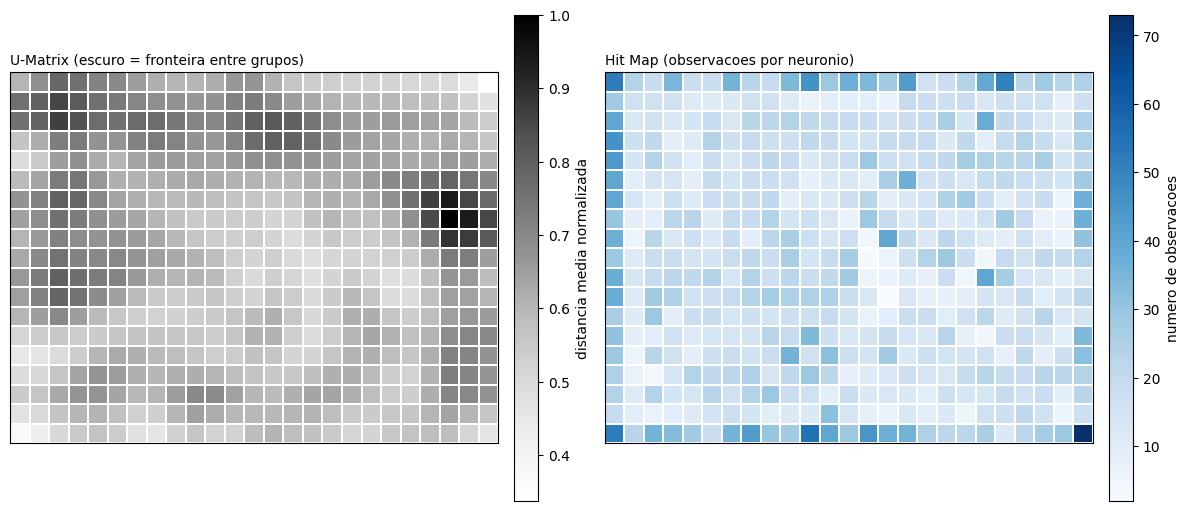

Neuronios vazios: 0 de 475
Observacoes por neuronio: mediana 17, maximo 73


In [7]:
def agrega_por_neuronio(valores, func='mean', min_hits=1, mascara=None):
    """Agrega `valores` (um por observacao) por neuronio; neuronios com menos de `min_hits` ficam NaN."""
    tab = pd.DataFrame({'x': df['bmu_x'], 'y': df['bmu_y'], 'v': valores})
    if mascara is not None:
        tab = tab[mascara]
    g = tab.groupby(['x', 'y'])['v']
    stats, hits = g.agg(func), g.count()
    grade = np.full((LINHAS, COLUNAS), np.nan)
    for (i, j), v in stats[hits >= min_hits].items():
        grade[i, j] = v
    return grade

def plot_mapa(ax, grade, titulo, cmap, label_cbar='', norm=None):
    cmap = plt.get_cmap(cmap).copy()
    cmap.set_bad('#e9e9e9')
    im = ax.pcolormesh(np.ma.masked_invalid(grade).T, cmap=cmap, norm=norm,
                       edgecolors='white', linewidth=0.3)
    ax.set_aspect('equal')
    ax.set_title(titulo, loc='left', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cb.set_label(label_cbar)
    return im

# media (e nao soma) das distancias aos vizinhos: evita que as bordas, com menos vizinhos, parecam mais claras
u_matrix = som.distance_map(scaling='mean')
hit_map = som.activation_response(X_som)      # numero de observacoes por neuronio

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_mapa(axes[0], u_matrix, 'U-Matrix (escuro = fronteira entre grupos)', 'Greys', 'distancia media normalizada')
plot_mapa(axes[1], hit_map, 'Hit Map (observacoes por neuronio)', 'Blues', 'numero de observacoes')
plt.tight_layout()
plt.show()

print(f'Neuronios vazios: {(hit_map == 0).sum()} de {hit_map.size}')
print(f'Observacoes por neuronio: mediana {np.median(hit_map):.0f}, maximo {hit_map.max():.0f}')

**U-Matrix:** não há "muralhas" contínuas e bem definidas separando o mapa em blocos; as distâncias variam de forma gradual. Isso indica que, no espaço dos sensores, os dados formam um **contínuo de estados**, e não grupos naturalmente separados. Faz sentido para medições horárias de poluição, que mudam aos poucos ao longo do dia e do ano. Ainda assim, há duas zonas mais escuras:
- **Lado direito, no meio (a mais escura do mapa):** protótipos distantes dos vizinhos. Como mostram os mapas de componentes (Seção 4.2), são leituras extremas do sensor `PT08.S3`, ou seja, situações raras e muito diferentes do restante.
- **Canto superior esquerdo:** região de alta poluição, onde as observações são mais espalhadas e menos frequentes, e os protótipos ficam mais distantes entre si.

As áreas mais claras (centro-inferior do mapa) representam o regime mais comum e homogêneo dos dados.

**Hit Map:** **nenhum neurônio ficou vazio** (475 de 475 usados). A ocupação é relativamente uniforme: mediana de 17 observações por neurônio, máximo de 73. Os neurônios das bordas, especialmente a linha inferior e a coluna da esquerda, recebem mais observações. Isso é o **efeito de borda** típico da SOM: os neurônios da borda absorvem as observações mais extremas da distribuição. Por isso, as bordas do mapa devem ser lidas como "regiões de valores extremos", e não necessariamente como estados mais frequentes.

### 4.2. Mapas de componentes

Cada mapa mostra o valor de **um atributo** nos protótipos dos neurônios (escala padronizada: 0 = média do dataset; vermelho = acima da média; azul = abaixo). Todos usam a mesma escala de cores, para que os mapas possam ser comparados entre si. Atributos com mapas parecidos são correlacionados.

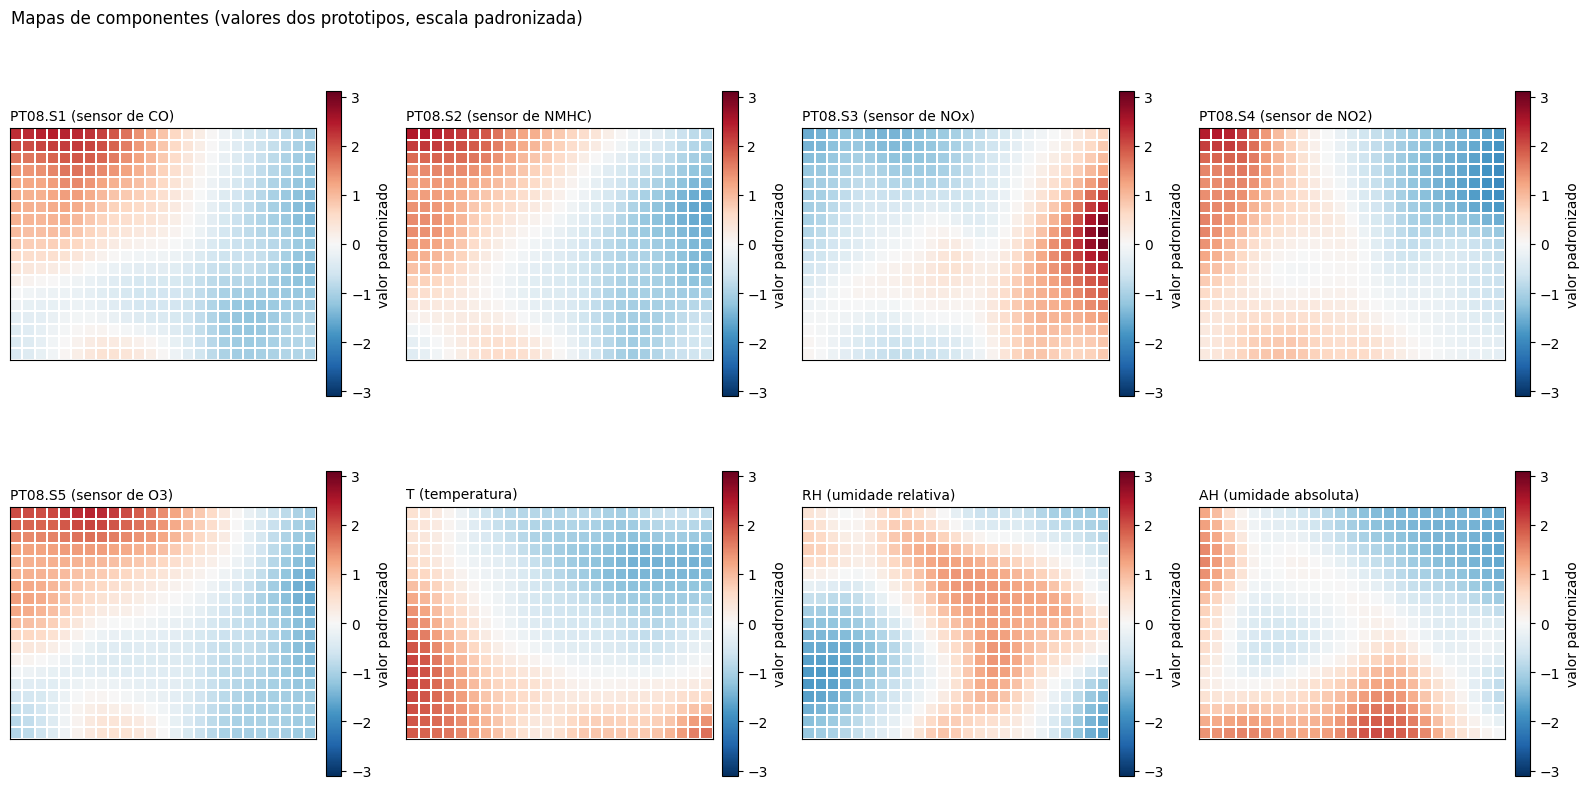

In [8]:
nomes_entradas = {
    'PT08.S1(CO)': 'PT08.S1 (sensor de CO)',
    'PT08.S2(NMHC)': 'PT08.S2 (sensor de NMHC)',
    'PT08.S3(NOx)': 'PT08.S3 (sensor de NOx)',
    'PT08.S4(NO2)': 'PT08.S4 (sensor de NO2)',
    'PT08.S5(O3)': 'PT08.S5 (sensor de O3)',
    'T': 'T (temperatura)',
    'RH': 'RH (umidade relativa)',
    'AH': 'AH (umidade absoluta)',
}
lim = np.abs(pesos).max()
norma = TwoSlopeNorm(vcenter=0, vmin=-lim, vmax=lim)

fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for k, (ax, atributo) in enumerate(zip(axes.ravel(), ENTRADAS_SOM)):
    plot_mapa(ax, pesos[:, :, k], nomes_entradas[atributo], 'RdBu_r', 'valor padronizado', norm=norma)
fig.suptitle('Mapas de componentes (valores dos prototipos, escala padronizada)', x=0.01, ha='left')
plt.tight_layout()
plt.show()

**Interpretação:**
- **`PT08.S1` (CO), `PT08.S2` (NMHC) e `PT08.S5` (O3) têm mapas quase idênticos:** valores altos no canto superior esquerdo, que diminuem em direção à direita. São sensores fortemente correlacionados entre si (correlação de 0,88 a 0,90) e juntos representam o **nível geral de poluição por emissões** (principalmente tráfego).
- **`PT08.S3` (NOx) tem o padrão inverso:** valores altos à direita, justamente onde os outros sensores estão baixos. A resistência desse sensor **aumenta quando a concentração de NOx diminui** (correlação de −0,77 a −0,80 com os demais). Seu valor máximo (≈ +3 desvios-padrão) fica no meio da borda direita, coincidindo com a zona mais escura da U-Matrix: situações de ar extremamente limpo.
- **`PT08.S4` (NO2)** acompanha os sensores de poluição no canto superior esquerdo, mas também é sensível às condições do ar (correlação de 0,63 com `AH` e 0,56 com `T`), com valores um pouco acima da média também na parte inferior esquerda.
- **Variáveis ambientais:** `T` é alta na parte inferior esquerda (dias quentes) e baixa na parte superior direita (frio). `AH` segue um padrão parecido (ar quente carrega mais vapor d'água). `RH` é alta em uma faixa central e baixa no canto inferior esquerdo, onde está o calor seco.

**Leitura geral:** o mapa se organiza em torno de **dois eixos**. Um, na diagonal do canto superior esquerdo para a direita, representa a **intensidade da poluição** (sensores). O outro, de baixo para cima, representa as **condições meteorológicas e a estação do ano** (temperatura e umidade). Isso corresponde à PCA: a 1ª componente (53% da variância) é dominada pelos sensores, e a 2ª (24%) pelas variáveis ambientais.

### 4.3. Distribuição da variável-alvo sobre o mapa

A variável-alvo **não participou do treinamento**. Depois do treino, cada observação é associada ao seu BMU, e calculamos a média e o desvio-padrão da concentração de benzeno das observações de cada neurônio. Se o mapa ficar organizado também em relação ao benzeno, a SOM terá descoberto, sem supervisão, a estrutura que a MLP aprende de forma supervisionada.

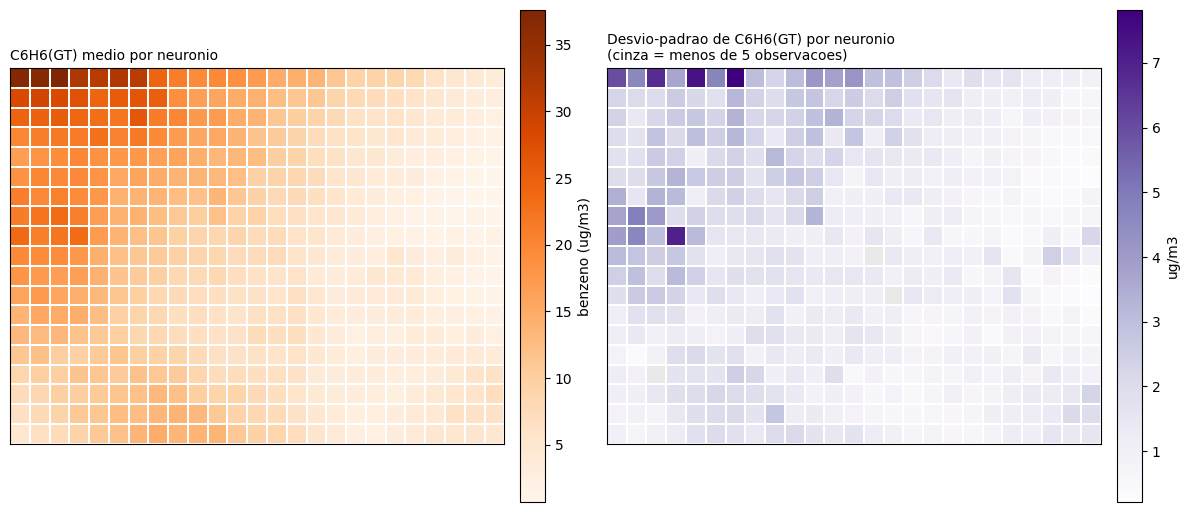

Variancia do benzeno explicada pela media do BMU: 93.5%


In [9]:
alvo_medio = agrega_por_neuronio(y, 'mean')
alvo_dp = agrega_por_neuronio(y, 'std', min_hits=5)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_mapa(axes[0], alvo_medio, 'C6H6(GT) medio por neuronio', 'Oranges', 'benzeno (ug/m3)')
plot_mapa(axes[1], alvo_dp, 'Desvio-padrao de C6H6(GT) por neuronio\n(cinza = menos de 5 observacoes)', 'Purples', 'ug/m3')
plt.tight_layout()
plt.show()

# Quanto da variancia do benzeno e explicada apenas pelo neuronio vencedor?
media_do_bmu = pd.Series(y).groupby([df['bmu_x'], df['bmu_y']]).transform('mean').values
r2_bmu = 1 - ((y - media_do_bmu) ** 2).sum() / ((y - y.mean()) ** 2).sum()
print(f'Variancia do benzeno explicada pela media do BMU: {100 * r2_bmu:.1f}%')

**Interpretação:** mesmo sem ter visto o benzeno no treinamento, a SOM organizou o mapa em um **gradiente suave de concentração**: de mais de 35 µg/m³ no canto superior esquerdo até cerca de 1 µg/m³ na borda direita. Esse gradiente acompanha os mapas dos sensores `PT08.S2`, `PT08.S1` e `PT08.S5`. A média de benzeno do neurônio vencedor explica **93,5% da variância** do benzeno. Ou seja, saber apenas "em que lugar do mapa" uma hora de medição cai já dá uma estimativa muito boa da concentração. Isso mostra, de forma não supervisionada, por que a MLP consegue R² ≈ 0,999: as leituras dos sensores de baixo custo já contêm quase toda a informação sobre o benzeno, principalmente `PT08.S2` (correlação > 0,98 com o alvo).

O mapa de desvio-padrão mostra que os neurônios de **alta concentração** (canto superior esquerdo, até ~7 µg/m³) são bem mais heterogêneos que os de baixa concentração (< 1 µg/m³). Os episódios de poluição intensa variam mais entre si, enquanto o ar limpo é um estado mais uniforme.

## 5. Análise integrada dos resultados

Para analisar o mapa por **regiões**, e não neurônio a neurônio, agrupamos os protótipos com **agrupamento hierárquico de Ward com restrição de vizinhança na malha**. Só neurônios adjacentes podem ser unidos, então cada região é uma área contínua do mapa. As regiões servem para *localizar*. Em seguida, cada uma é *caracterizada* pelos mapas de componentes e *confirmada* com estatísticas das observações associadas aos seus BMUs: contagens, benzeno, gases de referência medidos, hora e mês.

O número de regiões é escolhido pelo coeficiente de silhueta, calculado sobre as observações (cada uma recebe a região do seu BMU), junto com a coerência visual com a U-Matrix.

In [10]:
def conectividade_grade(linhas, colunas):
    """Matriz de adjacencia da malha retangular (vizinhos acima/abaixo/esquerda/direita)."""
    adj = lil_matrix((linhas * colunas, linhas * colunas))
    for i in range(linhas):
        for j in range(colunas):
            k = i * colunas + j
            if i + 1 < linhas:
                adj[k, k + colunas] = adj[k + colunas, k] = 1
            if j + 1 < colunas:
                adj[k, k + 1] = adj[k + 1, k] = 1
    return adj.tocsr()

prototipos = pesos.reshape(-1, pesos.shape[2])
conectividade = conectividade_grade(LINHAS, COLUNAS)
indice_bmu = df['bmu_x'].values * COLUNAS + df['bmu_y'].values
amostra = np.random.RandomState(RANDOM_STATE).choice(N, 3000, replace=False)

silhuetas = []
for k in range(2, 9):
    rotulos = AgglomerativeClustering(n_clusters=k, linkage='ward', connectivity=conectividade).fit_predict(prototipos)
    silhuetas.append({'n_regioes': k,
                      'silhueta': silhouette_score(X_som[amostra], rotulos[indice_bmu][amostra])})
pd.DataFrame(silhuetas).round(3)

,n_regioes,silhueta
0,2,0.239
1,3,0.206
2,4,0.191
3,5,0.170
4,6,0.173
5,7,0.165
6,8,0.159


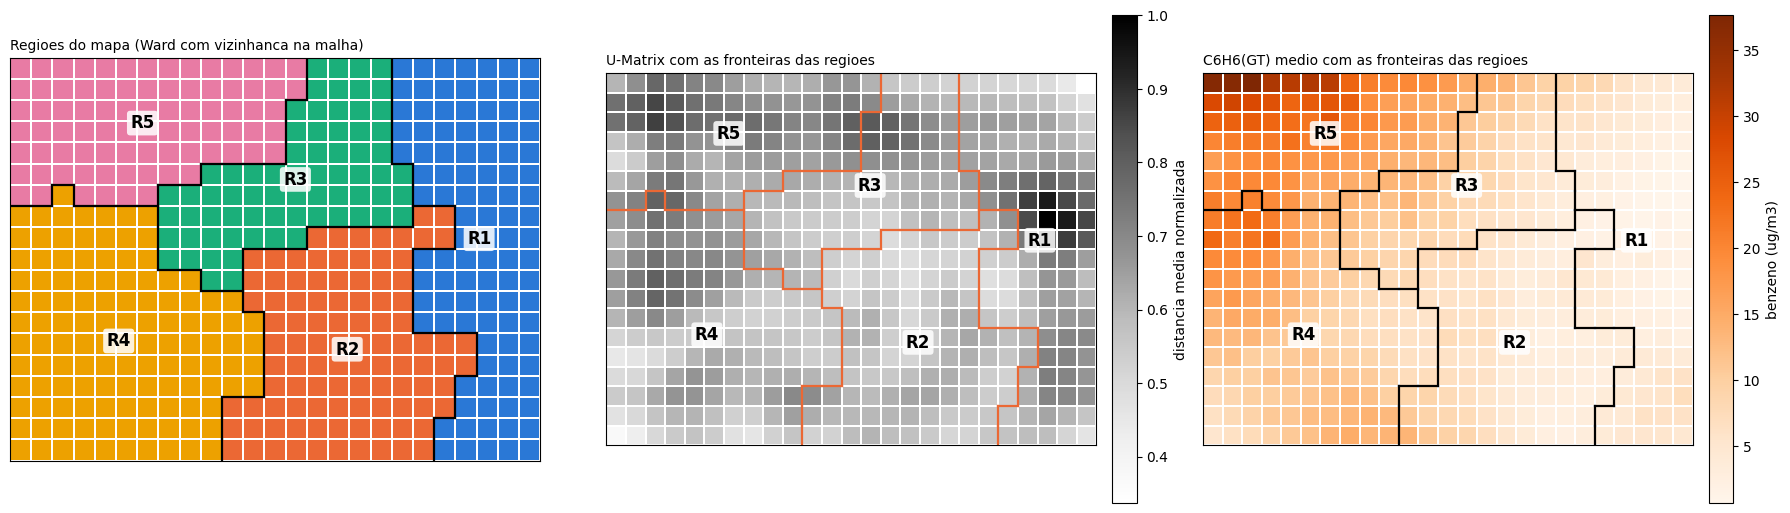

In [11]:
N_REGIOES = 5

rotulos_prot = AgglomerativeClustering(n_clusters=N_REGIOES, linkage='ward',
                                       connectivity=conectividade).fit_predict(prototipos)
# renumera as regioes em ordem crescente de benzeno medio (R1 = menor concentracao)
media_por_rotulo = pd.Series(y).groupby(rotulos_prot[indice_bmu]).mean().sort_values()
renumera = {antigo: novo for novo, antigo in enumerate(media_por_rotulo.index)}
regioes_grade = np.vectorize(renumera.get)(rotulos_prot).reshape(LINHAS, COLUNAS)
df['regiao'] = regioes_grade[df['bmu_x'], df['bmu_y']]
NOMES_REGIOES = [f'R{r + 1}' for r in range(N_REGIOES)]
cores_regioes = CORES_REGIOES[:N_REGIOES]

def desenha_fronteiras(ax, grade=regioes_grade, cor='black', lw=1.6):
    for i in range(LINHAS):
        for j in range(COLUNAS):
            if i + 1 < LINHAS and grade[i, j] != grade[i + 1, j]:
                ax.plot([i + 1, i + 1], [j, j + 1], color=cor, linewidth=lw)
            if j + 1 < COLUNAS and grade[i, j] != grade[i, j + 1]:
                ax.plot([i, i + 1], [j + 1, j + 1], color=cor, linewidth=lw)

def rotula_regioes(ax, grade=regioes_grade):
    for r in range(N_REGIOES):
        ii, jj = np.where(grade == r)
        ax.text(ii.mean() + 0.5, jj.mean() + 0.5, NOMES_REGIOES[r], ha='center', va='center',
                fontsize=12, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor='none'))

fig, axes = plt.subplots(1, 3, figsize=(18, 6.2))
ax = axes[0]
ax.pcolormesh(regioes_grade.T, cmap=ListedColormap(cores_regioes), edgecolors='white', linewidth=0.3)
ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title('Regioes do mapa (Ward com vizinhanca na malha)', loc='left', fontsize=10)
desenha_fronteiras(ax); rotula_regioes(ax)
plot_mapa(axes[1], u_matrix, 'U-Matrix com as fronteiras das regioes', 'Greys', 'distancia media normalizada')
desenha_fronteiras(axes[1], cor='#eb6834'); rotula_regioes(axes[1])
plot_mapa(axes[2], alvo_medio, 'C6H6(GT) medio com as fronteiras das regioes', 'Oranges', 'benzeno (ug/m3)')
desenha_fronteiras(axes[2]); rotula_regioes(axes[2])
plt.tight_layout()
plt.show()

In [12]:
inverno = df['month'].isin([11, 12, 1, 2])
pico = df['hour'].isin([7, 8, 9, 17, 18, 19, 20])
madrugada = df['hour'].between(0, 5)
fim_de_semana = df['dayofweek'] >= 5

perfil = df.groupby('regiao').agg(
    neuronios=('bmu_x', lambda s: df.loc[s.index, ['bmu_x', 'bmu_y']].drop_duplicates().shape[0]),
    observacoes=(ALVO, 'size'),
    benzeno_medio=(ALVO, 'mean'),
    benzeno_mediana=(ALVO, 'median'),
    benzeno_p90=(ALVO, lambda s: s.quantile(0.9)),
    **{f'{g}_medido': (g, 'mean') for g in GASES_REF},
    T_media=('T', 'mean'),
    RH_media=('RH', 'mean'),
    AH_media=('AH', 'mean'),
)
perfil.insert(2, '%_dados', 100 * perfil['observacoes'] / N)
perfil['%_inverno_nov_fev'] = 100 * inverno.groupby(df['regiao']).mean()
perfil['%_horario_pico'] = 100 * pico.groupby(df['regiao']).mean()
perfil['%_madrugada_0_5h'] = 100 * madrugada.groupby(df['regiao']).mean()
perfil['%_fim_de_semana'] = 100 * fim_de_semana.groupby(df['regiao']).mean()
perfil.index = NOMES_REGIOES
print('Referencia (dataset inteiro): '
      f'benzeno medio {y.mean():.2f} | inverno {100 * inverno.mean():.1f}% | pico {100 * pico.mean():.1f}% | '
      f'madrugada {100 * madrugada.mean():.1f}% | fim de semana {100 * fim_de_semana.mean():.1f}%')
perfil.round(2).T

Referencia (dataset inteiro): benzeno medio 10.08 | inverno 29.6% | pico 29.1% | madrugada 25.0% | fim de semana 29.4%


,R1,R2,R3,R4,R5
neuronios,103.00,100.00,70.00,120.00,82.00
observacoes,2038.00,1677.00,1251.00,2375.00,1650.00
%_dados,22.67,18.65,13.91,26.42,18.35
benzeno_medio,3.77,5.37,8.85,11.89,21.00
benzeno_mediana,3.50,4.80,8.70,11.20,19.70
benzeno_p90,6.80,9.30,13.20,18.30,30.31
CO(GT)_medido,1.04,1.14,2.12,2.20,4.16
NOx(GT)_medido,131.50,122.09,297.17,170.08,523.87
NO2(GT)_medido,88.59,68.85,136.01,113.43,155.15
T_media,13.83,18.69,10.74,27.39,16.18


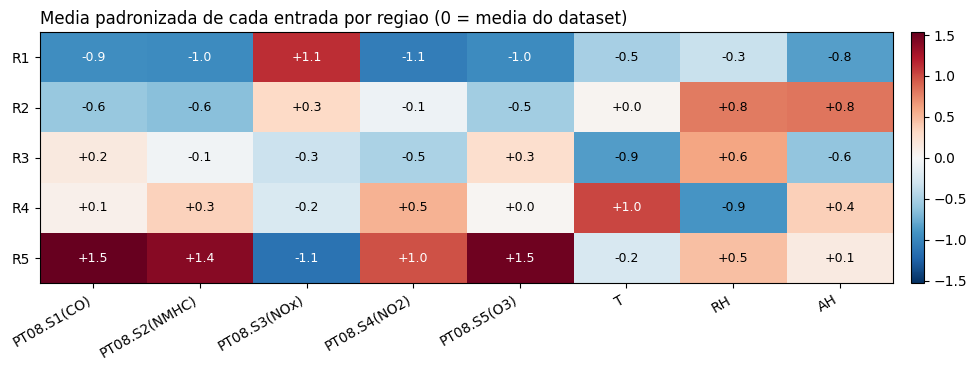

In [13]:
# Medias padronizadas das entradas por regiao (mesma informacao dos mapas de componentes, resumida)
perfil_entradas = pd.DataFrame(X_som, columns=ENTRADAS_SOM).groupby(df['regiao']).mean()
perfil_entradas.index = NOMES_REGIOES

fig, ax = plt.subplots(figsize=(10, 3.8))
lim_p = np.abs(perfil_entradas.values).max()
im = ax.imshow(perfil_entradas.values, cmap='RdBu_r', norm=TwoSlopeNorm(0, -lim_p, lim_p), aspect='auto')
ax.set_xticks(range(len(ENTRADAS_SOM)), ENTRADAS_SOM, rotation=30, ha='right')
ax.set_yticks(range(N_REGIOES), NOMES_REGIOES)
for i in range(N_REGIOES):
    for j in range(len(ENTRADAS_SOM)):
        v = perfil_entradas.values[i, j]
        ax.text(j, i, f'{v:+.1f}', ha='center', va='center', fontsize=9,
                color='white' if abs(v) > 0.6 * lim_p else 'black')
ax.grid(False)
ax.set_title('Media padronizada de cada entrada por regiao (0 = media do dataset)', loc='left')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
plt.tight_layout()
plt.show()

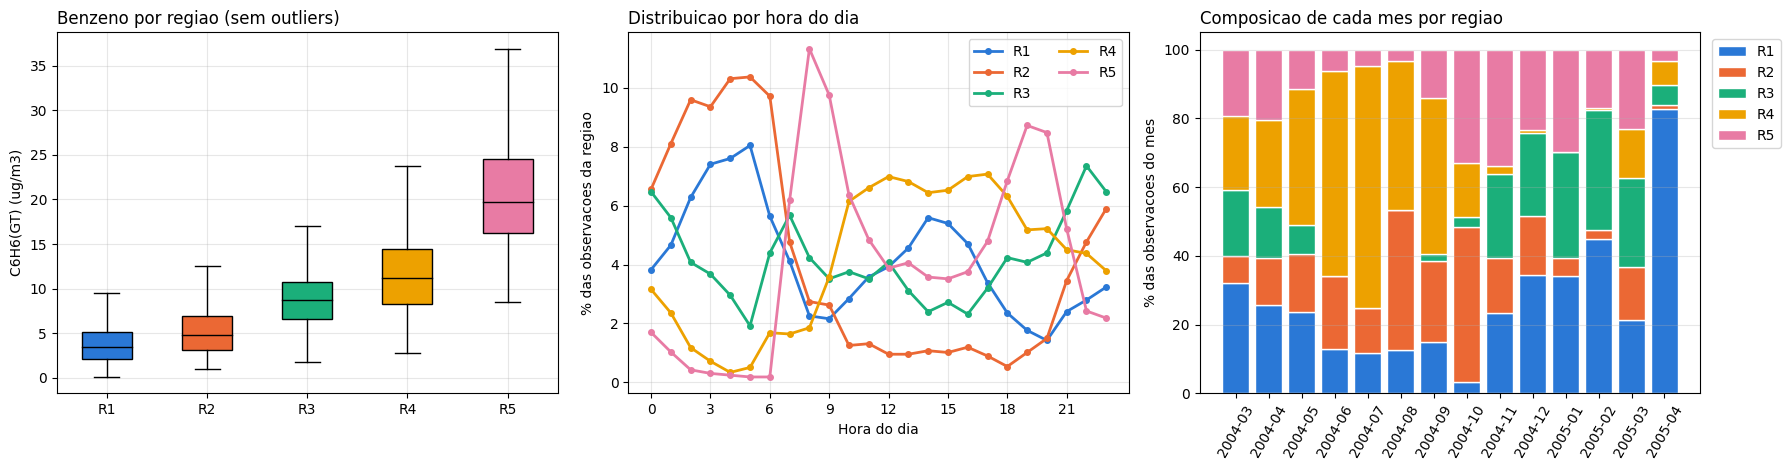

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# benzeno por regiao
partes = axes[0].boxplot([y[df['regiao'] == r] for r in range(N_REGIOES)], labels=NOMES_REGIOES,
                         patch_artist=True, showfliers=False, medianprops=dict(color='black'))
for caixa, cor in zip(partes['boxes'], cores_regioes):
    caixa.set_facecolor(cor)
axes[0].set_ylabel('C6H6(GT) (ug/m3)')
axes[0].set_title('Benzeno por regiao (sem outliers)', loc='left')

# perfil horario: fracao das observacoes de cada regiao em cada hora
horas = pd.crosstab(df['hour'], df['regiao'], normalize='columns') * 100
for r in range(N_REGIOES):
    axes[1].plot(horas.index, horas[r], marker='o', markersize=4, linewidth=2,
                 color=cores_regioes[r], label=NOMES_REGIOES[r])
axes[1].set_xlabel('Hora do dia')
axes[1].set_ylabel('% das observacoes da regiao')
axes[1].set_xticks(range(0, 24, 3))
axes[1].set_title('Distribuicao por hora do dia', loc='left')
axes[1].legend(ncol=2)

# composicao mensal: fracao de cada regiao em cada mes
meses = pd.crosstab(df['DateTime'].dt.to_period('M'), df['regiao'], normalize='index') * 100
base = np.zeros(len(meses))
for r in range(N_REGIOES):
    axes[2].bar(meses.index.astype(str), meses[r], bottom=base, color=cores_regioes[r],
                label=NOMES_REGIOES[r], edgecolor='white', linewidth=1)
    base += meses[r].values
axes[2].set_ylabel('% das observacoes do mes')
axes[2].set_title('Composicao de cada mes por regiao', loc='left')
axes[2].tick_params(axis='x', rotation=60)
axes[2].legend(loc='upper left', bbox_to_anchor=(1.01, 1))
axes[2].grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

**Escolha do número de regiões:** a silhueta é baixa para qualquer número de regiões (0,16 a 0,24) e diminui à medida que o número cresce. Isso confirma o que a U-Matrix mostra: os dados formam um contínuo, e não grupos bem separados. Com 2 regiões, o mapa seria dividido apenas em "mais poluído" e "menos poluído", o que pouco acrescenta. Escolhemos **5 regiões**, cuja silhueta (0,170) é praticamente igual à de 6 (0,173). Com elas o mapa se divide em regimes interpretáveis, e as duas zonas mais escuras da U-Matrix ficam em regiões distintas (canto superior esquerdo em R5; borda direita em R1). As regiões devem ser lidas como **trechos de um contínuo** (regimes típicos), e não como grupos com limites rígidos. Elas foram numeradas em ordem crescente de benzeno médio.

**Referência para comparação (dataset inteiro):** benzeno médio 10,1 µg/m³; 29,6% das observações no inverno (nov–fev); 29,1% em horário de pico (7–9h e 17–20h); 25,0% de madrugada (0–5h); 29,4% em fins de semana.

---

**R5 — horários de pico de tráfego (benzeno muito alto)**
- **Localizar:** canto superior esquerdo do mapa (18,4% das observações). Corresponde a uma das zonas mais escuras da U-Matrix e à região de maior concentração no mapa da variável-alvo.
- **Caracterizar:** os sensores de poluição estão muito acima da média (`PT08.S1` +1,5, `PT08.S2` +1,4, `PT08.S5` +1,5, `PT08.S4` +1,0 desvio-padrão), e `PT08.S3` está muito abaixo (−1,1), o que indica NOx alto. A temperatura fica próxima da média.
- **Confirmar:** benzeno médio de **21,0 µg/m³** (mediana 19,7; 10% das horas acima de 30,3), o dobro de qualquer outra região. Os gases medidos pelo analisador de referência confirmam: CO de 4,2 mg/m³ e NOx de 524 ppb, os maiores do mapa. **56% das observações estão em horário de pico** (contra 29% no geral), só 3,9% são de madrugada e 16,8% são de fim de semana, a menor fração entre as regiões. O perfil horário é bimodal, com picos às 8h e às 19–20h, exatamente os horários de ida e volta do trabalho.
- **O que revela:** os episódios de benzeno mais altos são poluição de **tráfego nos horários de pico de dias úteis**, presentes o ano todo (mais frequentes no outono e no inverno).

**R4 — dias quentes de verão (benzeno moderado a alto)**
- **Localizar:** parte inferior esquerda, a maior região do mapa (26,4% das observações), em área clara da U-Matrix (regime homogêneo).
- **Caracterizar:** temperatura bem acima da média (+1,0), umidade relativa baixa (−0,9), `PT08.S4` acima da média (+0,5) e os demais sensores próximos da média.
- **Confirmar:** temperatura média de 27,4 °C e umidade relativa de 33%. Apenas 1% das observações é de inverno, e elas dominam junho e julho de 2004 (≈ 60–70% de cada mês). As observações se concentram entre 10h e 18h, com só 8% de madrugada. Benzeno médio de 11,9 µg/m³.
- **O que revela:** é o regime das **tardes quentes e secas de verão**. A atividade é diurna e o benzeno fica um pouco acima da média.

**R3 — noites e fins de tarde de inverno (benzeno intermediário)**
- **Localizar:** faixa central superior do mapa (13,9% das observações), entre R5 e R1.
- **Caracterizar:** frio (`T` −0,9), umidade absoluta baixa (−0,6) e umidade relativa alta (+0,6), com os sensores de poluição próximos da média.
- **Confirmar:** temperatura média de 10,7 °C e **61% das observações no inverno** (a maior proporção). O NOx medido é alto (297 ppb, o 2º maior), e o benzeno médio é de 8,9 µg/m³. As observações se concentram à noite (21h–0h) e no início da manhã. Essa região representa ≈ 25–35% de cada mês entre novembro de 2004 e março de 2005, e quase não aparece no verão.
- **O que revela:** são as **noites frias de inverno**, com poluição ainda presente, provavelmente acumulada após o pico da tarde e pouco dispersa no ar frio.

**R2 — madrugadas úmidas fora do inverno (benzeno baixo)**
- **Localizar:** parte inferior central e direita (18,7% das observações), em área clara e homogênea da U-Matrix.
- **Caracterizar:** umidade alta (`RH` +0,8 e `AH` +0,8), temperatura na média e sensores de poluição moderadamente abaixo da média.
- **Confirmar:** benzeno médio de 5,4 µg/m³. **54% das observações são de madrugada** (a maior proporção) e só 14% em horário de pico. Apenas 17% são de inverno; a região é muito frequente em agosto e outubro de 2004.
- **O que revela:** são as **noites e madrugadas úmidas da primavera, do verão e do outono**, com pouco tráfego.

**R1 — ar limpo em dias frios (benzeno muito baixo)**
- **Localizar:** faixa da borda direita do mapa (22,7% das observações), que contém a zona mais escura da U-Matrix.
- **Caracterizar:** todos os sensores de poluição bem abaixo da média (≈ −1,0) e `PT08.S3` bem acima (+1,1), indicando pouco NOx. O ar é frio e seco (`T` −0,5, `AH` −0,8).
- **Confirmar:** benzeno médio de **3,8 µg/m³** (mediana 3,5), com CO de 1,0 mg/m³ e NOx de 132 ppb, os menores níveis. 38% das observações são de madrugada e 38,5% de fim de semana (as maiores proporções), e 44% são de inverno. O perfil horário tem picos de madrugada (3–5h) e no início da tarde (14–15h), horários de pouco tráfego ou de maior dispersão dos poluentes.
- **O que revela:** são os períodos de **ar limpo em dias frios**: madrugadas, fins de semana e algumas tardes. A zona mais escura da U-Matrix, dentro dessa região, reúne os casos extremos de ar muito limpo.

**Síntese:** a SOM mostra que o benzeno é governado principalmente pelo **ciclo do tráfego** (hora do dia e dia da semana), que separa R5 de R1/R2, e, em segundo plano, pela **estação do ano**, que separa R4 (verão) de R3/R1 (inverno). As regiões encontradas sem supervisão correspondem a padrões de calendário que **não foram usados no treinamento** (hora, dia da semana e mês), o que reforça que esses padrões são reais e não um artefato do mapa.

## 6. Relação com o trabalho de MLP

Para relacionar o mapa ao comportamento da MLP, treinamos novamente o **modelo final do trabalho de MLP**, com o mesmo pré-processamento, os mesmos 14 atributos (gases de referência imputados pela mediana), o mesmo holdout temporal (20% mais recentes) e a melhor configuração encontrada pelo TPE: 1 camada oculta de 16 neurônios, ReLU, SGD, `learning_rate_init` ≈ 0,0157, batch 32, paciência 10. O RMSE de teste deve reproduzir o valor do trabalho de MLP (0,162).

Cada observação do teste é então associada ao seu BMU na SOM. Assim podemos ver **onde, no mapa, ficam as observações do período de teste** e **se os erros da MLP se concentram em regiões específicas**. Para não tirar conclusões a partir de neurônios pouco ocupados, o erro por neurônio só é mostrado quando ele tem pelo menos 5 observações de teste, e as conclusões principais são tiradas por região.

In [15]:
ENTRADAS_MLP = ['CO(GT)', 'PT08.S1(CO)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)',
                'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'hour', 'month', 'dayofweek']
X_mlp = df[ENTRADAS_MLP].copy()
X_mlp[GASES_REF] = X_mlp[GASES_REF].fillna(X_mlp[GASES_REF].median())  # mesma imputacao do trabalho de MLP

idx_treino, idx_teste = train_test_split(np.arange(N), test_size=0.2, shuffle=False)
melhor_config_mlp = dict(hidden_layer_sizes=(16,), activation='relu', solver='sgd',
                         learning_rate_init=0.015667246197124923, batch_size=32, n_iter_no_change=10,
                         max_iter=200, early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE)
mlp = Pipeline([('scaler', StandardScaler()), ('mlp', MLPRegressor(**melhor_config_mlp))])
mlp.fit(X_mlp.values[idx_treino], y[idx_treino])

df['previsto_mlp'] = mlp.predict(X_mlp.values)
df['erro_mlp'] = y - df['previsto_mlp']            # positivo = MLP subestimou
df['erro_abs_mlp'] = df['erro_mlp'].abs()
df['conjunto'] = 'treino'
df.loc[idx_teste, 'conjunto'] = 'teste'
teste = (df['conjunto'] == 'teste').values

print(f'MLP  -> RMSE treino: {root_mean_squared_error(y[~teste], df.loc[~teste, "previsto_mlp"]):.3f} | '
      f'RMSE teste: {root_mean_squared_error(y[teste], df.loc[teste, "previsto_mlp"]):.3f} | '
      f'MAE teste: {mean_absolute_error(y[teste], df.loc[teste, "previsto_mlp"]):.3f}')
print('Periodo de teste:', df.loc[teste, 'DateTime'].min(), 'a', df.loc[teste, 'DateTime'].max())

MLP  -> RMSE treino: 0.102 | RMSE teste: 0.162 | MAE teste: 0.123
Periodo de teste: 2005-01-16 02:00:00 a 2005-04-04 14:00:00


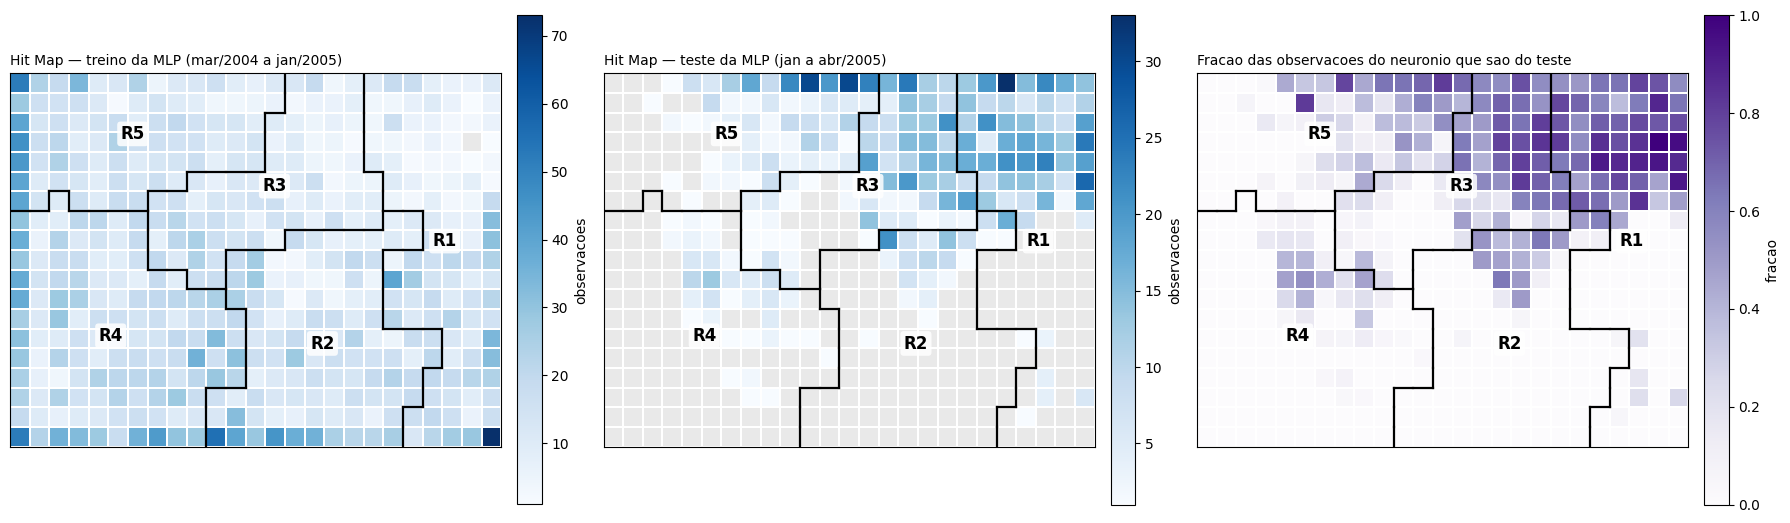

Neuronios com observacoes de teste: 218 de 475
Neuronios ocupados SO por observacoes de teste: 1


In [16]:
hits_treino = agrega_por_neuronio(np.ones(N), 'sum', mascara=~teste)
hits_teste = agrega_por_neuronio(np.ones(N), 'sum', mascara=teste)
frac_teste = agrega_por_neuronio(teste.astype(float), 'mean')

fig, axes = plt.subplots(1, 3, figsize=(18, 6.2))
plot_mapa(axes[0], hits_treino, 'Hit Map — treino da MLP (mar/2004 a jan/2005)', 'Blues', 'observacoes')
plot_mapa(axes[1], hits_teste, 'Hit Map — teste da MLP (jan a abr/2005)', 'Blues', 'observacoes')
plot_mapa(axes[2], frac_teste, 'Fracao das observacoes do neuronio que sao do teste', 'Purples', 'fracao')
for ax in axes:
    desenha_fronteiras(ax); rotula_regioes(ax)
plt.tight_layout()
plt.show()

print(f'Neuronios com observacoes de teste: {np.sum(~np.isnan(hits_teste))} de {LINHAS * COLUNAS}')
print(f'Neuronios ocupados SO por observacoes de teste: {np.sum(np.isnan(hits_treino) & ~np.isnan(hits_teste))}')

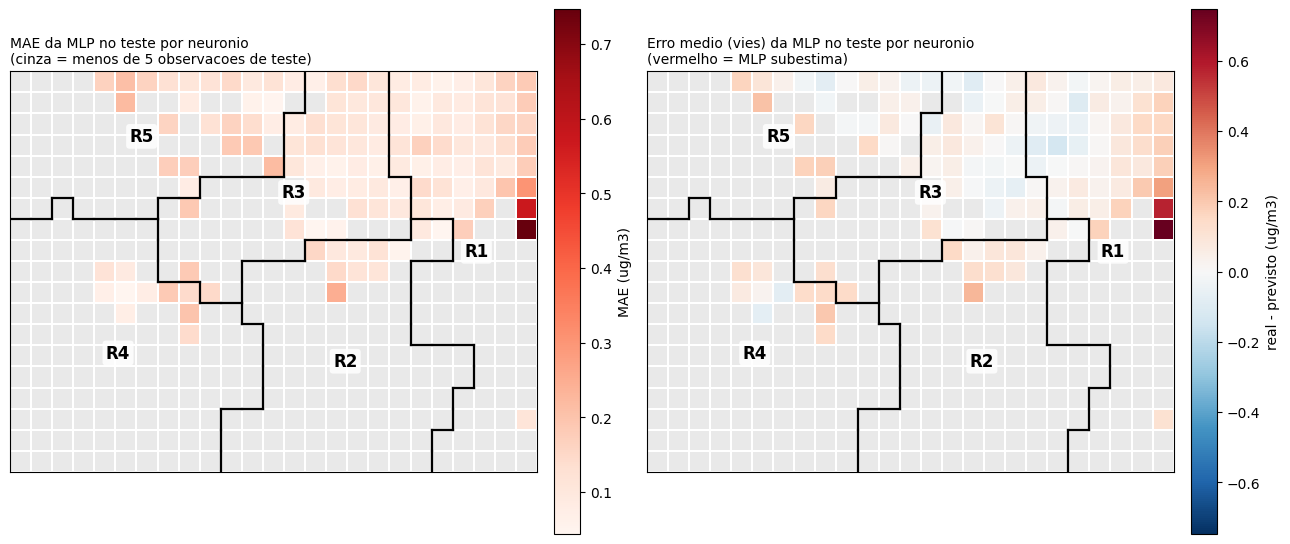

Neuronios com >= 5 observacoes de teste: 132


In [17]:
MIN_HITS_TESTE = 5
mae_teste = agrega_por_neuronio(df['erro_abs_mlp'].values, 'mean', min_hits=MIN_HITS_TESTE, mascara=teste)
vies_teste = agrega_por_neuronio(df['erro_mlp'].values, 'mean', min_hits=MIN_HITS_TESTE, mascara=teste)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))
plot_mapa(axes[0], mae_teste, f'MAE da MLP no teste por neuronio\n(cinza = menos de {MIN_HITS_TESTE} observacoes de teste)',
          'Reds', 'MAE (ug/m3)')
lim_v = np.nanmax(np.abs(vies_teste))
plot_mapa(axes[1], vies_teste, 'Erro medio (vies) da MLP no teste por neuronio\n(vermelho = MLP subestima)',
          'RdBu_r', 'real - previsto (ug/m3)', norm=TwoSlopeNorm(0, -lim_v, lim_v))
for ax in axes:
    desenha_fronteiras(ax); rotula_regioes(ax)
plt.tight_layout()
plt.show()

print(f'Neuronios com >= {MIN_HITS_TESTE} observacoes de teste: {np.sum(~np.isnan(mae_teste))}')

In [18]:
def resumo_erros(grupo):
    tr, te = grupo[grupo['conjunto'] == 'treino'], grupo[grupo['conjunto'] == 'teste']
    return pd.Series({
        'obs_treino': len(tr),
        'obs_teste': len(te),
        '%_do_teste': 100 * len(te) / teste.sum(),
        'benzeno_medio_teste': te[ALVO].mean(),
        'MAE_treino': tr['erro_abs_mlp'].mean(),
        'MAE_teste': te['erro_abs_mlp'].mean(),
        'RMSE_teste': np.sqrt((te['erro_mlp'] ** 2).mean()),
        'vies_teste': te['erro_mlp'].mean(),
        'MAE_relativo_teste_%': 100 * (te['erro_abs_mlp'] / te[ALVO]).median(),
    })

erros_regiao = df.groupby('regiao').apply(resumo_erros)
erros_regiao.index = NOMES_REGIOES
print(f'MAE de teste global: {df.loc[teste, "erro_abs_mlp"].mean():.3f} ug/m3')
erros_regiao.round(3)

MAE de teste global: 0.123 ug/m3


,obs_treino,obs_teste,%_do_teste,benzeno_medio_teste,MAE_treino,MAE_teste,RMSE_teste,vies_teste,MAE_relativo_teste_%
R1,1321.0,717.0,39.855,3.552,0.079,0.137,0.186,0.079,3.270
R2,1541.0,136.0,7.560,3.083,0.071,0.115,0.138,0.092,3.482
R3,764.0,487.0,27.071,7.667,0.073,0.101,0.123,0.015,1.166
R4,2261.0,114.0,6.337,10.087,0.062,0.110,0.136,0.083,1.012
R5,1305.0,345.0,19.177,18.228,0.100,0.134,0.173,0.046,0.619


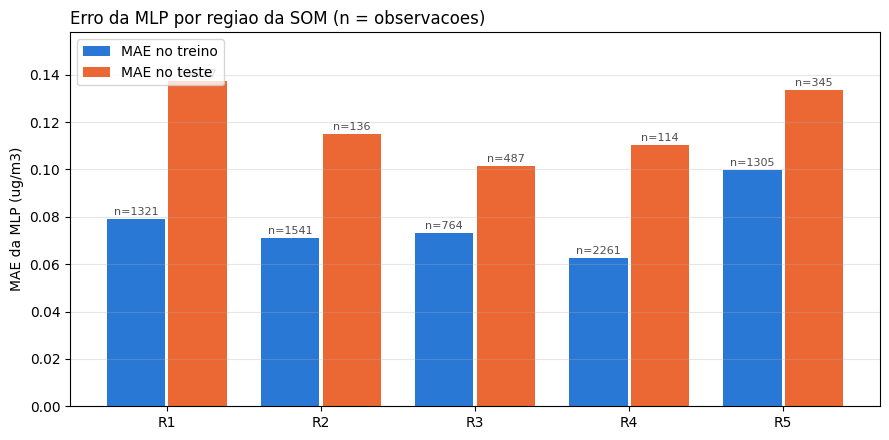

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.5))
pos = np.arange(N_REGIOES)
largura = 0.38
b1 = ax.bar(pos - largura / 2 - 0.01, erros_regiao['MAE_treino'], largura, color='#2a78d6', label='MAE no treino')
b2 = ax.bar(pos + largura / 2 + 0.01, erros_regiao['MAE_teste'], largura, color='#eb6834', label='MAE no teste')
for barras, n in ((b1, erros_regiao['obs_treino']), (b2, erros_regiao['obs_teste'])):
    for barra, qtd in zip(barras, n):
        if np.isfinite(barra.get_height()):
            ax.annotate(f'n={int(qtd)}', (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                        textcoords='offset points', xytext=(0, 3), ha='center', fontsize=8, color='0.3')
ax.set_xticks(pos, NOMES_REGIOES)
ax.set_ylabel('MAE da MLP (ug/m3)')
ax.set_title('Erro da MLP por regiao da SOM (n = observacoes)', loc='left')
ax.legend(loc='upper left')
ax.grid(axis='x', visible=False)
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

In [20]:
te = df[teste]
print('Vies medio da MLP no teste (real - previsto, ug/m3) por mes e regiao:')
vies_mes_regiao = te.pivot_table(index=te['DateTime'].dt.to_period('M'), columns='regiao',
                                 values='erro_mlp', aggfunc='mean')
vies_mes_regiao.columns = NOMES_REGIOES
display(vies_mes_regiao.round(3))

print('Erro da MLP no teste por faixa de concentracao real:')
faixas = pd.cut(te[ALVO], [0, 2, 5, 10, 20, 70])
display(te.groupby(faixas).agg(observacoes=('erro_abs_mlp', 'size'), MAE=('erro_abs_mlp', 'mean'),
                               vies=('erro_mlp', 'mean')).round(3))
negativas = te[te['previsto_mlp'] < 0]
print(f'Previsoes negativas no teste: {len(negativas)} '
      f'(regioes: {negativas["regiao"].map(lambda r: NOMES_REGIOES[r]).value_counts().to_dict()})')

# neuronios com maior MAE no teste (>= MIN_HITS_TESTE observacoes de teste)
piores = (te.groupby(['bmu_x', 'bmu_y'])
            .agg(obs_teste=('erro_abs_mlp', 'size'), MAE=('erro_abs_mlp', 'mean'), benzeno=(ALVO, 'mean'),
                 PT08_S3=('PT08.S3(NOx)', 'mean'), T_teste=('T', 'mean'), regiao=('regiao', 'first')))
piores = piores[piores['obs_teste'] >= MIN_HITS_TESTE].sort_values('MAE', ascending=False).head(5)
piores['T_treino_mesmo_neuronio'] = [df.loc[(df['bmu_x'] == i) & (df['bmu_y'] == j) & ~teste, 'T'].mean()
                                     for i, j in piores.index]
piores['regiao'] = piores['regiao'].map(lambda r: NOMES_REGIOES[r])
print(f'Percentil 99 de PT08.S3(NOx) no dataset: {df["PT08.S3(NOx)"].quantile(0.99):.0f}')
piores.round(3)

Vies medio da MLP no teste (real - previsto, ug/m3) por mes e regiao:


,R1,R2,R3,R4,R5
DateTime,,,,,
2005-01,0.091,0.120,-0.029,NaN,-0.024
2005-02,0.061,0.007,-0.017,-0.011,-0.023
2005-03,0.071,0.101,0.064,0.090,0.114
2005-04,0.125,0.143,0.170,-0.018,0.073


Erro da MLP no teste por faixa de concentracao real:


,observacoes,MAE,vies
C6H6(GT),,,
"(0, 2]",244,0.181,0.152
"(2, 5]",534,0.118,0.076
"(5, 10]",517,0.103,0.018
"(10, 20]",394,0.112,0.035
"(20, 70]",110,0.160,0.002


Previsoes negativas no teste: 20 (regioes: {'R1': 20})
Percentil 99 de PT08.S3(NOx) no dataset: 1664


obs_teste    MAE  benzeno   PT08_S3  T_teste regiao  \
bmu_x bmu_y                                                        
24    11             5  0.747    0.160  1776.400    3.460     R1   
      12            18  0.573    0.350  1611.889    3.028     R1   
      13            26  0.304    0.662  1385.000    3.215     R1   
15    8              7  0.247    3.286   790.857   15.014     R2   
5     17             9  0.222   25.122   410.556   17.622     R5   

             T_treino_mesmo_neuronio  
bmu_x bmu_y                           
24    11                      11.331  
      12                      10.147  
      13                       6.800  
15    8                       13.275  
5     17                      14.650

**Onde está o período de teste no mapa?** As observações de teste (16/01 a 04/04/2005) ocupam 218 dos 475 neurônios, e **só 1 neurônio é ocupado exclusivamente pelo teste**. Ou seja, o período de teste não cria um "estado novo" que o treino nunca viu; ele fica dentro da estrutura aprendida. Mas a **distribuição** muda bastante: 40% do teste cai em R1, 27% em R3 e 19% em R5. Os regimes de verão quase não aparecem (R2 com 7,6% e R4 com 6,3%, contra 18,7% e 26,4% no dataset todo). Isso mostra no mapa a **mudança de distribuição** discutida na Seção 10 do trabalho de MLP: o teste é um período de inverno e início de primavera, com mais ar limpo e mais concentrações baixas (no mapa "Fração das observações do neurônio que são do teste", a metade superior direita aparece roxa).

**Os erros da MLP se concentram em alguma região?**
- **O erro aumenta em todas as regiões** do treino para o teste (MAE de 0,06–0,10 → 0,10–0,14 µg/m³). Isso é coerente com a perda de desempenho ao prever um período futuro.
- **R1 (ar limpo) tem o maior MAE de teste (0,137)**, seguida de R5 (0,134). Em termos relativos, R1 e R2 são as piores (erro mediano de ≈ 3,3–3,5% do valor real, contra 0,6% em R5), porque o mesmo erro absoluto pesa muito mais quando a concentração é baixa. A tabela por faixa de concentração confirma: abaixo de 2 µg/m³, o MAE é 0,181 e o viés é +0,152, enquanto entre 5 e 20 µg/m³ o MAE fica em 0,10–0,11.
- **Os piores neurônios estão na borda direita de R1**, exatamente na zona mais escura da U-Matrix. Neles, o MAE de teste chega a 0,75, 0,57 e 0,30 µg/m³, com 5, 18 e 26 observações de teste, contra o MAE global de 0,123. São horas de ar extremamente limpo (benzeno de 0,2 a 0,7 µg/m³, `PT08.S3` acima do seu percentil 99 de 1.664), mas, no teste, **muito mais frias** (≈ 3 °C) do que as observações de treino desses mesmos neurônios (≈ 7–11 °C). A MLP precisa **extrapolar** para uma combinação de sensores e temperatura rara no treino e erra o sinal: **todas as 20 previsões negativas do teste**, fisicamente impossíveis, estão em R1.
- **R5 tem o maior erro absoluto já no treino** (MAE 0,100), coerente com a maior variabilidade do benzeno nos episódios de alta concentração (mapa de desvio-padrão da Seção 4.3). No teste, porém, o erro relativo de R5 é o menor (0,6%).
- **O viés é positivo em quase todo o teste** (a MLP subestima o benzeno real), e a tabela por mês mostra que ele cresce em março e abril em praticamente todas as regiões (+0,06 a +0,17). Esse componente do erro é **temporal**, e não ligado a um regime específico. Ele pode estar associado a mudanças graduais nos sensores ou nas condições ao longo do tempo, e só é visível com o holdout temporal.

**Cuidados com neurônios pouco ocupados:** o pior neurônio tem apenas 5 observações de teste, então seu MAE isolado não é confiável. A conclusão sobre a borda direita de R1 se apoia no fato de que os três neurônios vizinhos com mais observações (18 e 26) mostram o mesmo padrão, e na análise por região e por faixa de concentração, todas com centenas de observações. Neurônios com menos de 5 observações de teste foram omitidos dos mapas de erro.

**Implicações para a MLP:**
1. **Previsões negativas:** limitar as previsões a valores ≥ 0, ou modelar o logaritmo da concentração, evitaria as previsões impossíveis em R1.
2. **Faltam exemplos de inverno com ar muito limpo:** o treino tem poucos casos de ar muito limpo em temperaturas tão baixas. Retreinar o modelo periodicamente, com dados mais recentes, reduziria a extrapolação.
3. **Monitoramento por região:** a SOM pode ser usada para isso: se novas medições caírem em neurônios pouco ocupados no treino, a previsão da MLP para elas merece menos confiança.

## 7. Conclusões da equipe

1. **O mapa é fiel e bem organizado.** A SOM 25 × 19 representou bem os 8 atributos de entrada (erro de quantização de 0,766) e preservou a topologia (erro topográfico de 1,9%), sem neurônios vazios.
2. **O benzeno pode ser lido no mapa.** Sem usar a variável-alvo, a SOM ordenou o mapa em um gradiente de benzeno que explica 93,5% da sua variância, seguindo os sensores `PT08.S2`, `PT08.S1` e `PT08.S5`. Isso explica, de forma não supervisionada, o desempenho muito alto da MLP no trabalho anterior.
3. **Os dados formam um contínuo, organizado por dois fatores.** A U-Matrix e a silhueta baixa mostram que não há grupos bem separados. O mapa se organiza em torno da **intensidade do tráfego** (hora do dia, dia útil ou fim de semana) e das **condições meteorológicas e da estação**. As cinco regiões correspondem a regimes reconhecíveis: ar limpo em dias frios (R1), madrugadas úmidas (R2), noites de inverno (R3), tardes de verão (R4) e horários de pico (R5). Esses regimes foram confirmados com hora, dia da semana, mês e gases de referência, nenhum deles usado no treinamento.
4. **A SOM explica onde a MLP erra.** O período de teste da MLP está concentrado nos regimes de inverno (R1, R3 e R5). O maior erro relativo está no ar muito limpo (R1), onde a MLP extrapola para condições mais frias que as do treino e chega a prever valores negativos. Também há um viés temporal (subestimação crescente em março e abril) que afeta todas as regiões.
5. **Limitações.** As regiões são uma segmentação de um contínuo, e suas fronteiras são aproximadas. A SOM foi treinada com todo o período, o que é adequado para análise exploratória, mas não para monitorar dados futuros. Conclusões sobre neurônios com poucas observações devem ser evitadas.